<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/Dataset_%26_DataLoader_Class_in_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

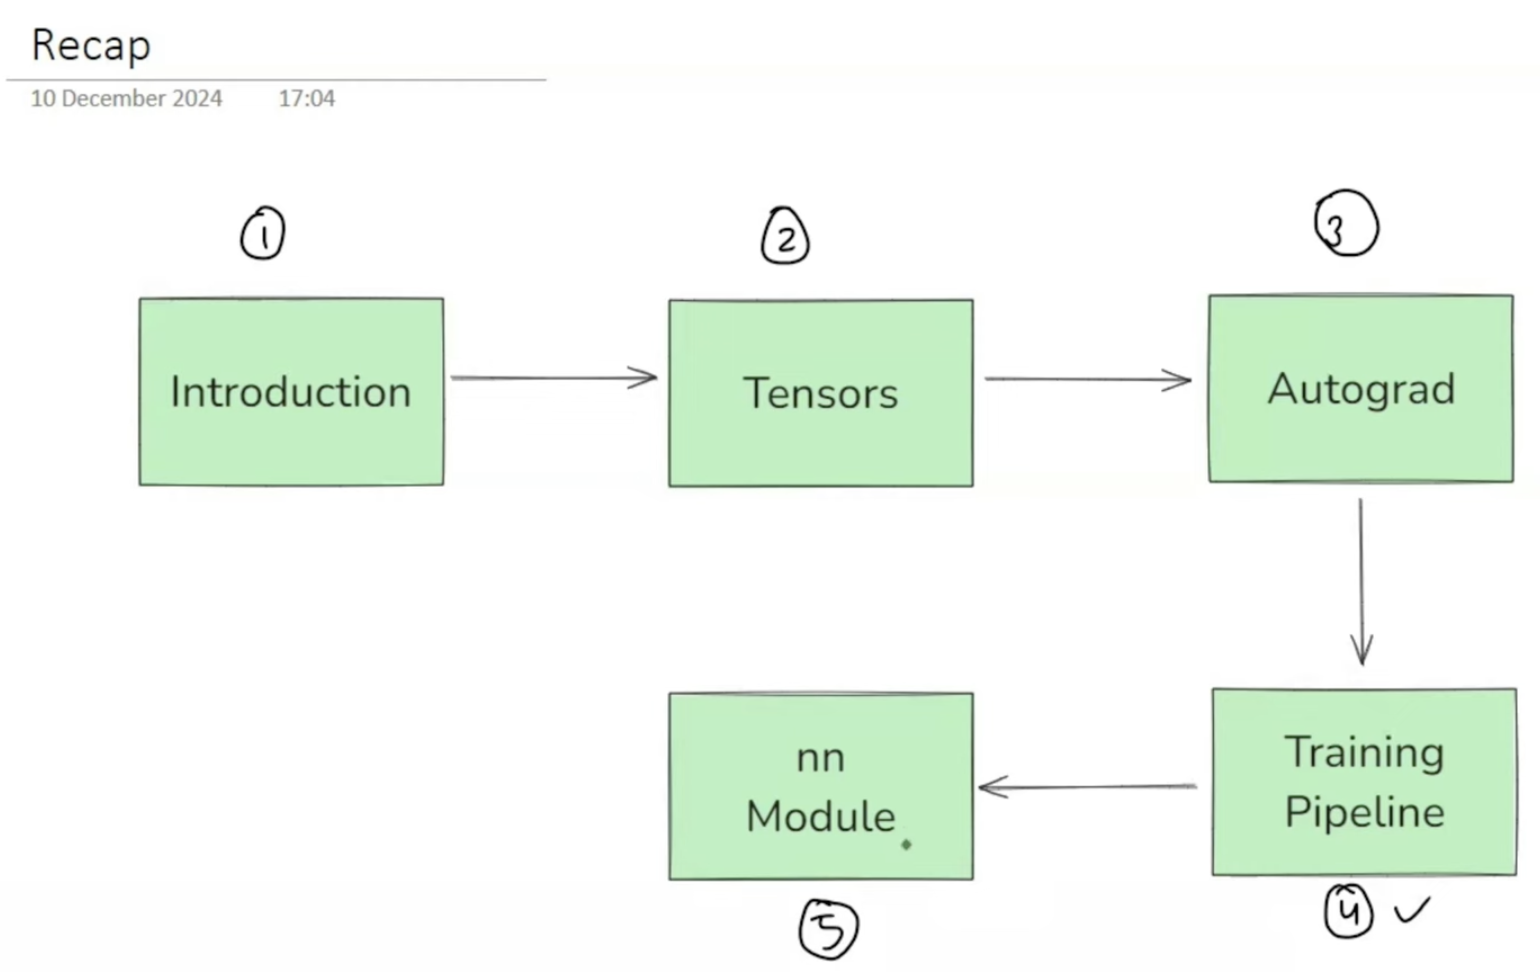

there is a code which we got from the pytorch_training pipeline we building a nn by self with cancer dataset now there is a training flow and there is a big problem

problem is ->  when we during training the model we are useing gradient decent is Batch Gradient Descent

Batch Gradient Descent mean one time change the parameter we use whole the dataset there is a big problem

mean

we perform on whole dataset forword pass -> then lose_calculate then ->  clear gradients then ->  backword pass then -> parameter update

for training model we perform a step we are useing whole dataset


# **correct version**
















We are building a custom neural network in PyTorch using a cancer dataset, but our current training pipeline has a major performance bottleneck. Right now, we are using Batch Gradient Descent. This means that to make a single update to the model's parameters, the code must process the entire dataset at once.

Our current training loop follows this heavy cycle for every single step:

Run a forward pass on the whole dataset.

Calculate the total loss.

Clear the old gradients.

Run a backward pass across the entire dataset.

Update the parameters.

Because the model has to look at every single data point before updating the weights even once, the training process is incredibly slow and memory-intensive.

# **problems**

normally during training we dont use batch gradient descent beacouse

gradient descent beacouse has 2 najor problems

memory inefficient -> a whole dataset sent in the ram and its use high computation

Batch Gradient Descent (BGD) mein convergence ka matlab hai ke jab model poore dataset ka error baar baar calculate karta hai, toh woh ahista ahista seekhte h

When we update the parameters using Stochastic Gradient Descent, we perform an update after looking at every single row.

BGD aur SGD mein yehi sab se barra farq hai:

Batch Gradient Descent (BGD): Poora dataset dekhne ke baad 1 update karta hai. (Bohot slow aur heavy hota hai).

Stochastic Gradient Descent (SGD): Har ek single row dekhne ke baad 1 update karta hai. (Bohot fast hota hai, lekin iska rasta bohot bhatakta/zigzag hota hai kyunki har row alag hoti hai).

SGD ka Roman Urdu mein Process (Flow):
Har single row ke liye yeh loop chalta hai:

1 Row ka forward pass karo.

Us 1 Row ka loss nikalo.

Gradients clear karo.

Backward pass karo.

Parameters update karo.

In [ ]:

import torch
import torch.nn as nn
class mysimplenn(nn.Module):

  # use built_in activation function
    def __init__(self, num_features):
        super().__init__()
      # x.shape[1] means number of features
        self.linear = nn.Linear(num_features , 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)
        return out


        # we will not use this lose function becous this create by its self we will use built_in loss function

    # def loss_function(self, y_pred, y):
    #     # avoid log(0)
    #     # Hum is liye use karte hain taake prediction exactly 0 ya 1 na ban jaye.
    #     epsilon = 1e-7

    #     # torch.clamp() keeps y_pred between 0.0000001 and 0.9999999
    #     # so the loss calculation does not break.
    #     y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    #     # make y shape same as y_pred
    #     y = y.view(-1, 1).type_as(y_pred)

    #     # binary cross entropy loss
    #     loss = -(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred)).mean()

    #     return loss








In [ ]:
# create model
model = mysimplenn(x_train_tensor.shape[1])

optimizer = torch.optim.SGD(model.parameters(), lr =learning_rate)

# define loop  -> hum ya jo 4 steps han in ko loop man kerty hain
# kitny dafa hum loop chlay gay ? -> jitni hum nay epoch set kia hai remmeber this words
for epoch in range(epochs):
# 1 .forword pass
   y_pred = model(x_train_tensor)
   #print(y_pred)

# 2 .loss calculate
   loss = loss_function(y_pred , y_train_tensor.view(-1,1)) # .view keyword use for the reshape


# # zeros gradiants
#    model.linear.weight.grad.zero_()
#    model.linear.bias.grad.zero_()
# clear gradients -> its a good things when we do lose backwords before we must be gradients zero
   optimizer.zero_grad() # now automatically convert zero gradients


# 3 .backword pass

   loss.backward()

# its a difficult beacouse we are making the code by self logic so that is why its tough its a simple way is use optim function

# # 4 .parameter update
   optimizer.step()
# # its a imp step
#    with torch.no_grad():
#      model.linear.weight -= learning_rate * model.linear.weight.grad
#      model.linear.bias -= learning_rate * model.linear.bias.grad




   # print each epoch utems
   print(f'epoch :"{epoch + 1} , Loss : {loss.item()}')


NameError: name 'x_train_tensor' is not defined

If I have 1,000 rows of data, we first divide the data into batches of 100 rows each; this is called **Mini-batch Gradient Descent**.

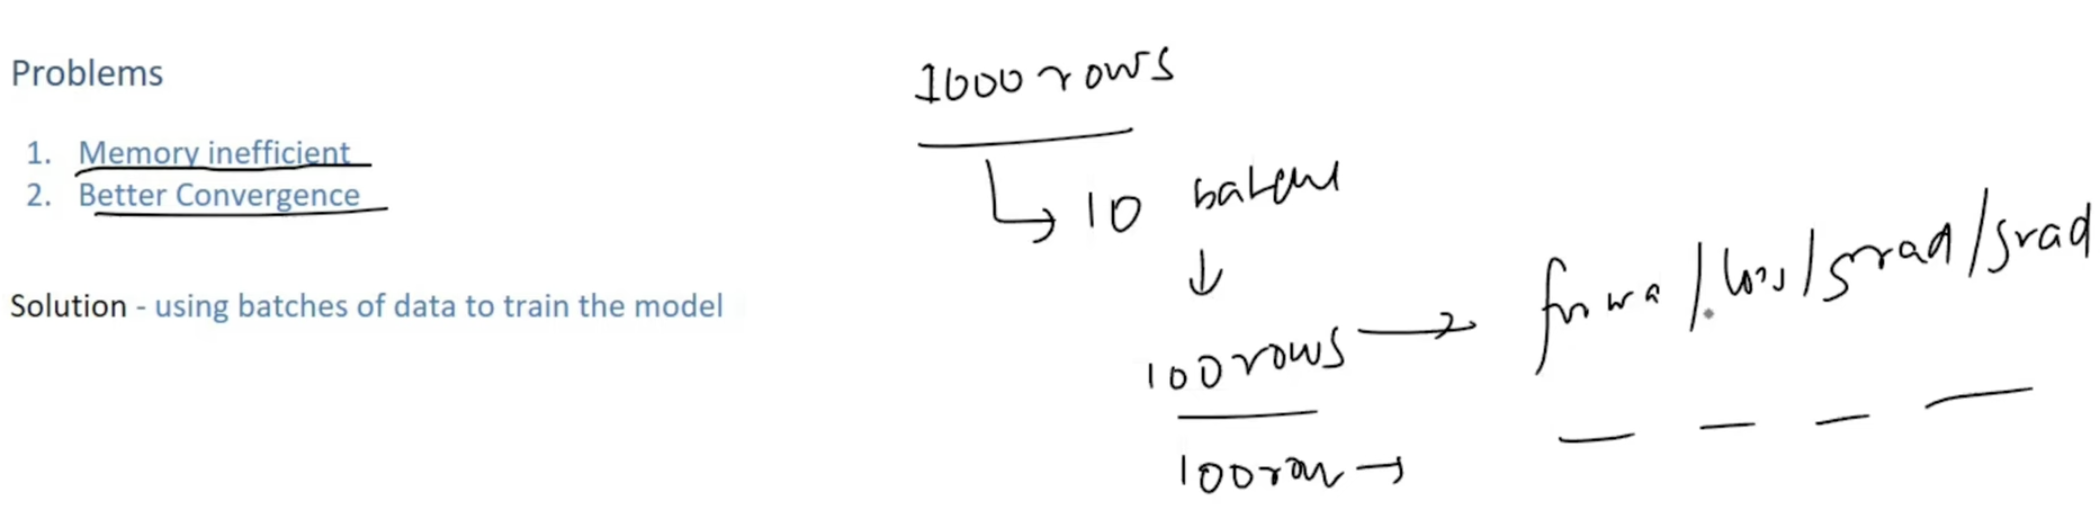

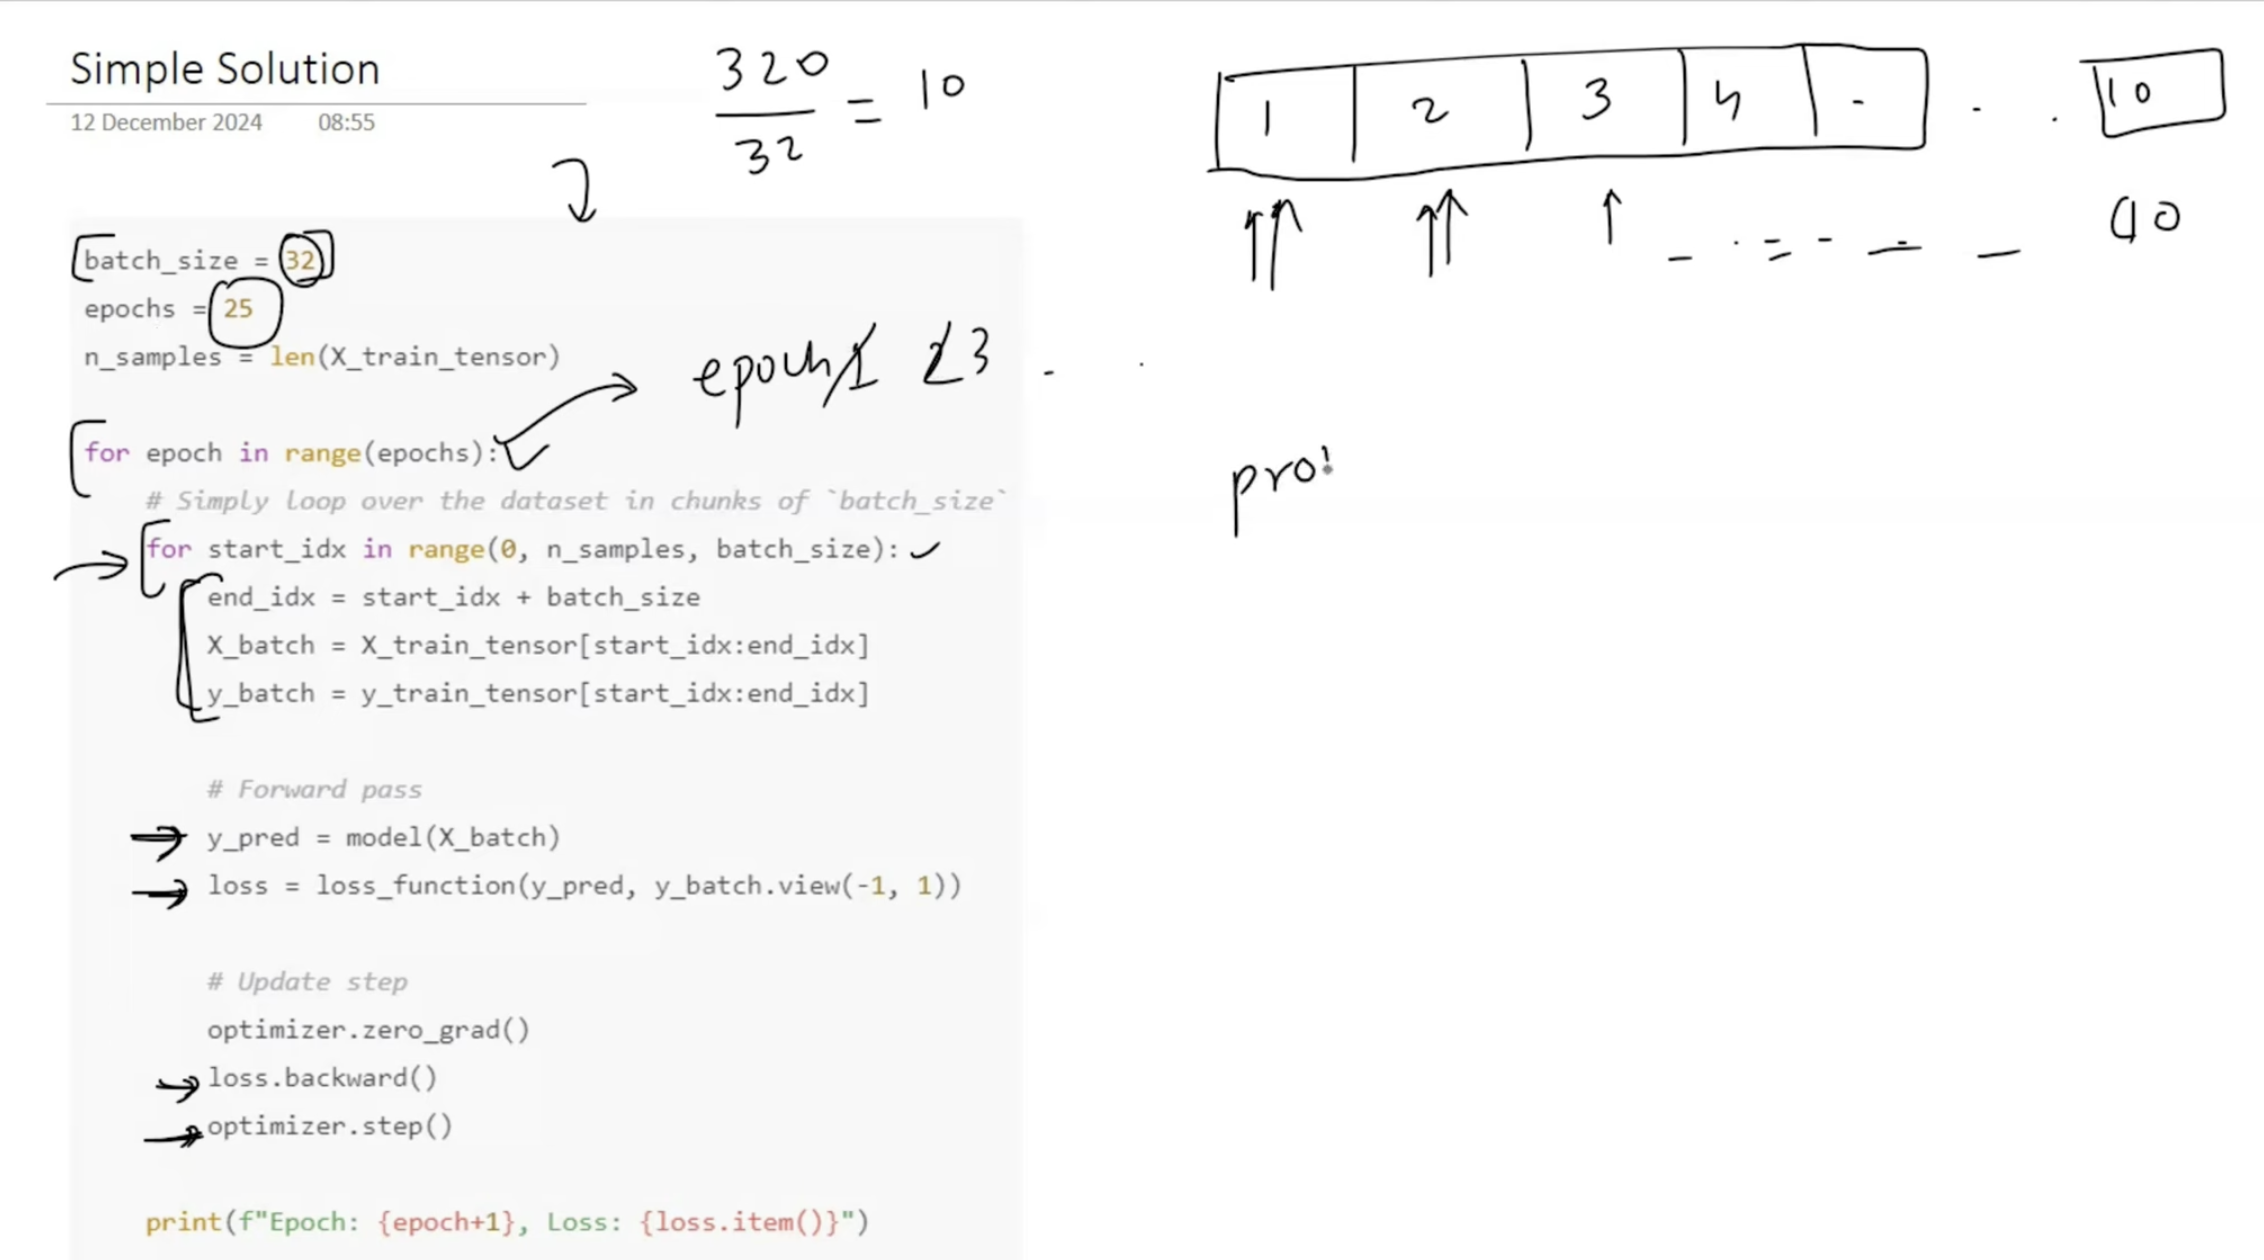

Data ko Tukron mein Torna: Humare paas total 320 rows hain. Humne tay kiya ke hum ek baari mein sirf 32 rows process karenge (batch_size = 32). Is tarah poora data 10 chote batches mein divide ho gaya.

The Outer Loop (Epochs): epochs = 25 ka matlab hai ke model is poori training process ko (yaani saare 10 batches ko parhne ka kaam) shuru se aakhiri tak 25 martaba dohrayega taake woh achi tarah seekh sake.

The Inner Loop (Batch Slicing): Yeh loop pure dataset mein se ek-ek karke 32 rows ka tukra kaat-ta hai (X_batch aur y_batch). Isme rows 32 hoti hain aur columns (features) saare ke saare sath aate hain.

The PyTorch Flow (Har Batch Par): Har ek batch ke sath yeh 5 steps hote hain:

Forward Pass: Model 32 rows ka prediction nikalta hai.

Loss Calculation: Dekha jata hai ke model ne kitni ghalti ki.

Zero Grad: Purane batch ke gradients ko saaf (clear) kiya jata hai.

Backward Pass: Ghalti ka hisab lagaya jata hai (gradients calculate hote hain).

Optimizer Step: Model ke parameters (weights) ko thoda sa behtar kar diya jata hai.

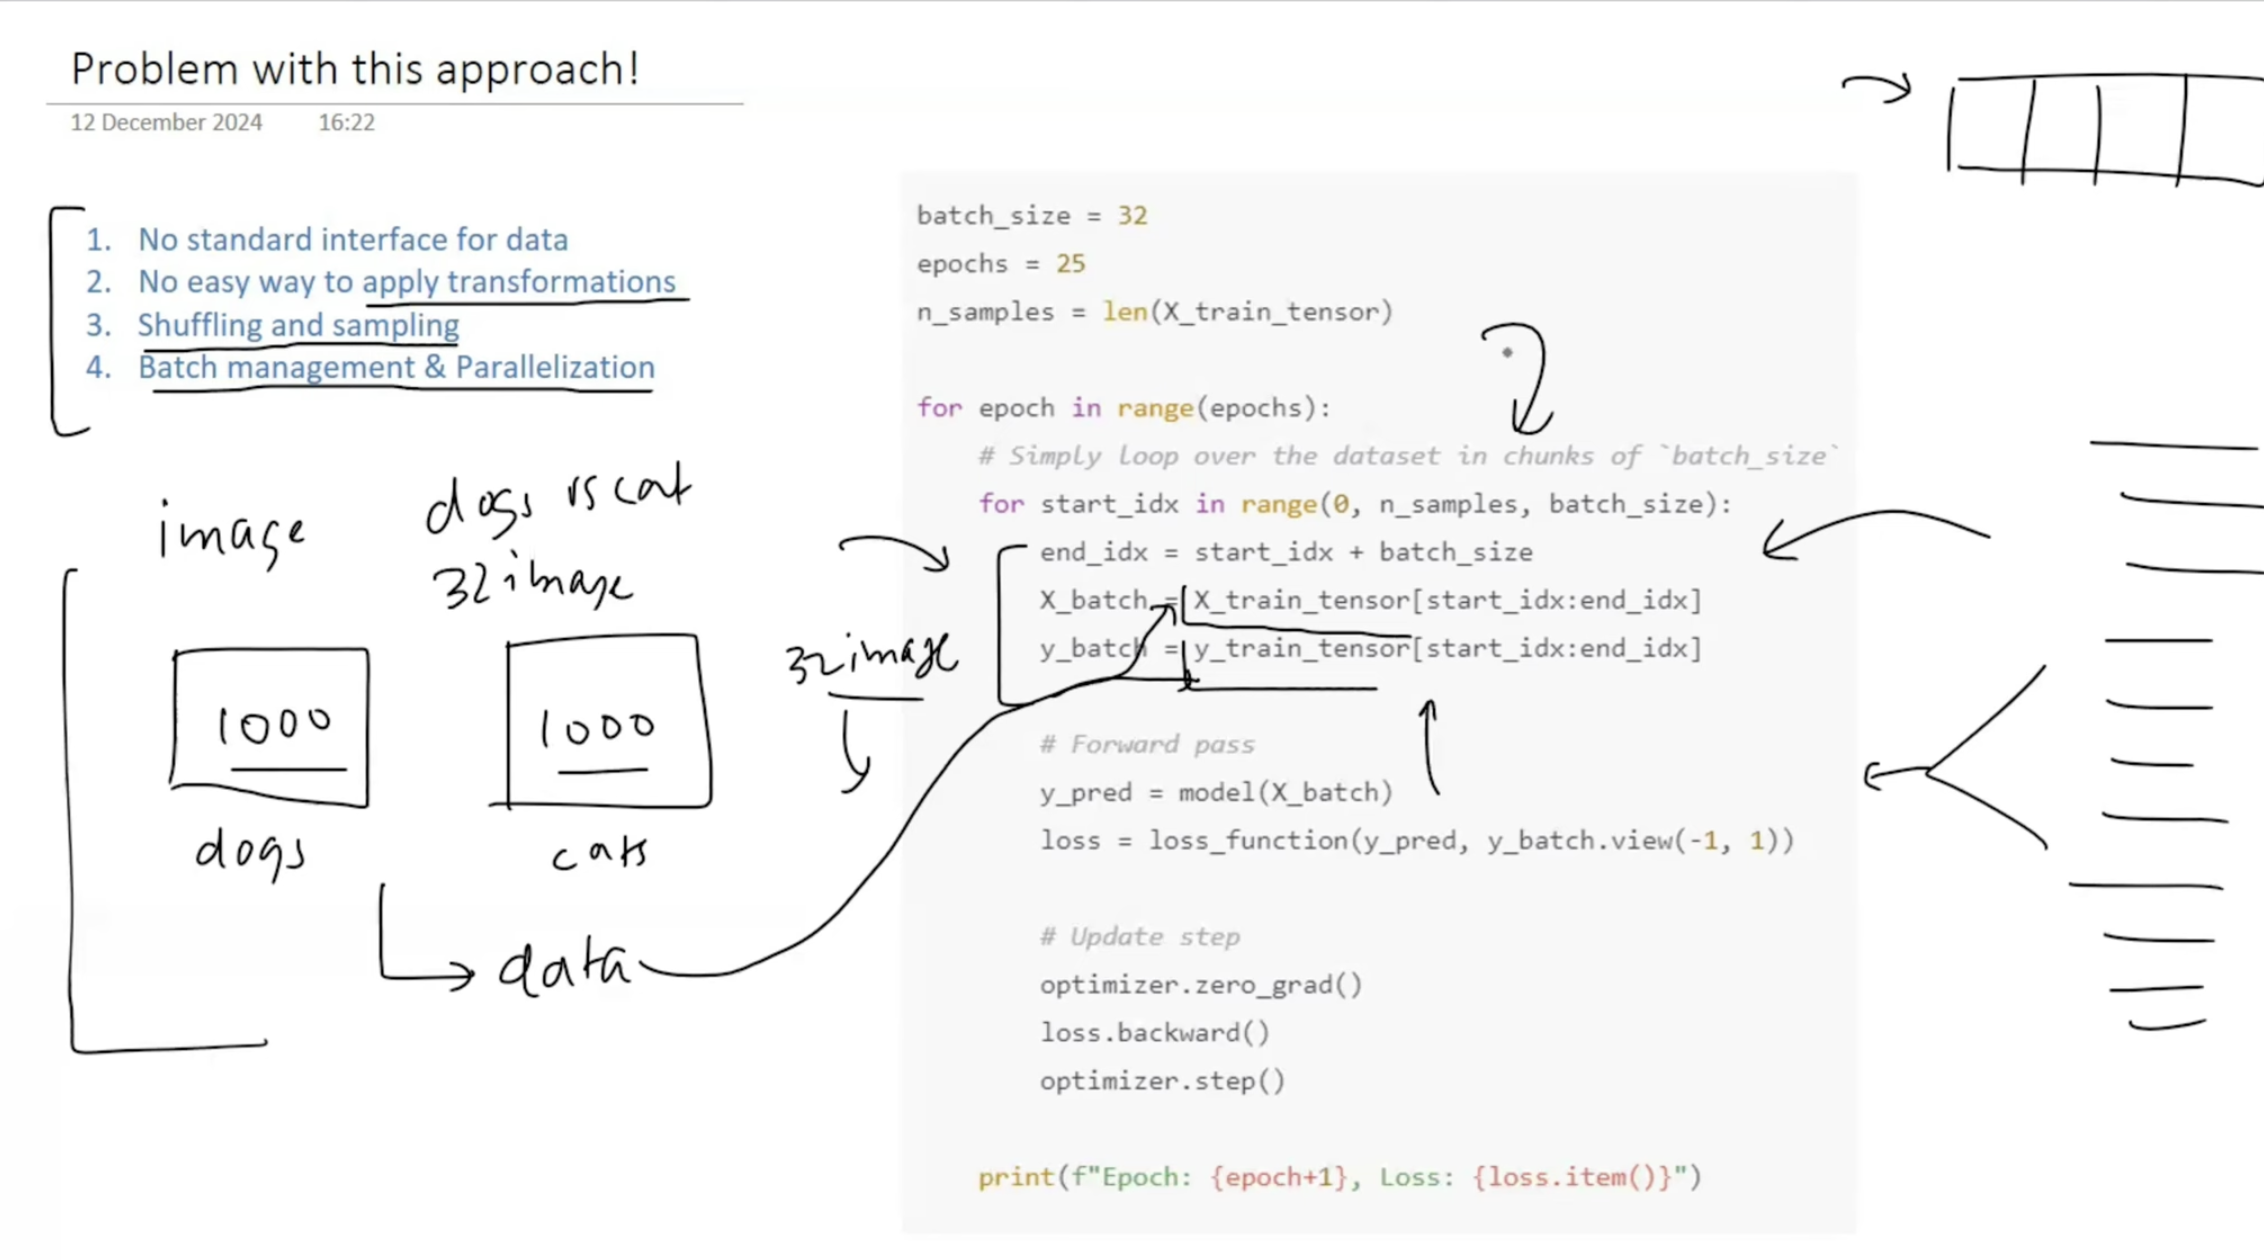

# **Left Side: 4 Bade Masle (Problems)**
Agar aap manual loops chala kar data ko [start_idx:end_idx] ke zariye kaat-te hain, toh yeh 4 mushkilat aati hain:

**No standard interface for data**: Har baar aapko alag tarah ka data handle karne ke liye naya aur lamba code likhna padega. Koi ek fixed, asaan tareeqa nahi banta.

**No easy way to apply transformations**: Agar aapko data par koi badlao karna ho (jaise images ka size chota karna, ya cancer data ko scale/normalize karna), toh manual loop mein har batch par alag se code likhna bohot mushkil ho jata hai.

**Shuffling and sampling**: Model ko hamesha data shuffled (mix) kar ke dena chahiye (jaise taash ke patte phente hain). Agar pehle saare dogs hain aur phir saare cats, toh model sahi se nahi seekhega. Manual code mein har round (epoch) se pehle data ko sahi se mix karna bohot jhanjhat ka kaam hai.

**Batch management & Parallelization**: Aapka computer ya laptop data ko fast process karne ke liye GPU (graphics card) use karta hai jo parallel kaam karta hai. Yeh manual loop computer ke processors ko poori tarah efficiently use nahi kar pata, jis se training slow hoti hai.

**Left-Cente**r: Dogs vs Cats ki Misaal (Images Problem)
Whiteboard par drawing ke zariye samjhaya gaya hai:

Sochein aapke paas 1,000 Dogs ki images hain aur 1,000 Cats ki images hain.

Agar aap seedha loop chalayenge bina mix kiye, toh pehle saare batches mein sirf dogs ki images chali jayengi aur baad wale batches mein sirf cats ki.

Model pehle sirf dogs dekh kar confuse ho jayega aur sahi se seekh nahi payega.

**Right Side**: Lines ka Matlab
Jo right side par lines bani hui hain, woh yeh dikha rahi hain ke real-world data hamesha ek sequence mein seedha nahi hota. Usme upar-neeche alag-alag tarah ka data hota hai, jise manage karne ke liye manual code chota pad jata hai.

# **Solution (Hal kya hai?)**
Inhi 4 maslon ko khatam karne ke liye PyTorch hume do ready-made tools deta hai:

Dataset (Jo data ko standard tareeqe se load karta hai).

DataLoader (Jo automatic data ko mix/shuffle bhi karta hai, batches bhi banata hai, aur speed bhi fast karta hai).

In [1]:
print("now start the code ")

now start the code 
